# 06 — Model & Session Analysis

Visual audit of HAR checkpoints: holdout **F1 / accuracy**, confusion matrix, **confidence outliers**, **embedding PCA clusters**, session logs, and **historical comparison** across every checkpoint in `checkpoints/`.

Outputs are saved under `outputs/har_analysis/<date>_<model_tag>/` (charts, CSVs, `REPORT.md`).

> **Tip:** Use `split='random'` for fair cross-checkpoint comparison. `split='subject'` is only meaningful when embeddings carry diverse `subjects` metadata.

In [16]:
import sys
from pathlib import Path

NB = Path.cwd() if Path.cwd().name == "notebooks" else Path.cwd() / "notebooks"
sys.path.insert(0, str(NB))

from lib.paths import ensure_notebook_paths

ensure_notebook_paths()
from lib.reload import reload_lib_modules

reload_lib_modules()  # pick up latest har_analysis.py after edits

import pandas as pd
from IPython.display import Image, Markdown, display

from lib.paths import CHECKPOINTS_DIR, OUTPUTS_DIR
from lib.har_analysis import (
    benchmark_all_checkpoints,
    load_analysis_history,
    load_checkpoint_registry,
    run_extended_analysis,
    eval_checkpoint_on_embeddings,
    resolve_npz_for_checkpoint,
)

## Configuration

In [17]:
# Latest crop-aligned 12-class model (change to compare others)
CURRENT_CKPT = CHECKPOINTS_DIR / "har_vjepa_12c_crop_100each.pt"
if not CURRENT_CKPT.is_file():
    pts = sorted(CHECKPOINTS_DIR.glob("har_vjepa_*.pt"))
    CURRENT_CKPT = pts[-1] if pts else None

HOLDOUT_SPLIT = "random"       # 'random' | 'subject' | 'full'
BENCHMARK_SPLIT = "random"     # same split for leaderboard across checkpoints

print("Checkpoint:", CURRENT_CKPT)
if CURRENT_CKPT:
    print("Embeddings:", resolve_npz_for_checkpoint(CURRENT_CKPT))

Checkpoint: /Users/cpanoh/Documents/cpano-98-local/GitHub/AI-Co-Pilot-for-the-Production-Floor-See-Guide-Improve/notebooks/checkpoints/har_vjepa_12c_crop_100each.pt
Embeddings: /Users/cpanoh/Documents/cpano-98-local/GitHub/AI-Co-Pilot-for-the-Production-Floor-See-Guide-Improve/notebooks/outputs/embeddings.npz


## Extended analysis — current checkpoint

Runs holdout eval + session charts + PCA/outlier plots + full-checkpoint benchmark.

In [18]:
if CURRENT_CKPT is None:
    raise FileNotFoundError("No checkpoint in notebooks/checkpoints/ — run 00_Pipeline first.")

result = run_extended_analysis(
    CURRENT_CKPT,
    split=HOLDOUT_SPLIT,
    benchmark_split=BENCHMARK_SPLIT,
)
summary = result["summary"]
out_dir = Path(result["out_dir"])
print(f"Saved to {out_dir}")
pd.Series({k: summary[k] for k in ("model_tag", "n_train", "n_test", "accuracy", "macro_f1", "weighted_f1", "n_live_events")})

Saved to /Users/cpanoh/Documents/cpano-98-local/GitHub/AI-Co-Pilot-for-the-Production-Floor-See-Guide-Improve/notebooks/outputs/har_analysis/2026-06-08_12c_crop_100each


model_tag        12c_crop_100each
n_train                       856
n_test                        214
accuracy                 0.443925
macro_f1                 0.409697
weighted_f1              0.416703
n_live_events                 109
dtype: object

In [19]:
display(Markdown("### Per-class metrics"))
display(result["metrics_df"].style.background_gradient(subset=["f1", "precision", "recall"], cmap="YlGn", vmin=0, vmax=1))

display(Markdown("### Checkpoint leaderboard (re-evaluated now)"))
bench = result["benchmark"]
cols = [c for c in ["model_tag", "n_classes", "n_test", "accuracy", "macro_f1", "weighted_f1", "npz"] if c in bench.columns]
display(bench[cols].style.background_gradient(subset=["macro_f1", "accuracy"], cmap="Blues", vmin=0, vmax=1))

### Per-class metrics

,class,precision,recall,f1,support
0,Consult sheets,0.344828,0.500000,0.408163,20.000000
1,Picking in front,0.444444,0.200000,0.275862,20.000000
2,Picking left,0.608696,0.700000,0.651163,20.000000
3,Put down component,0.629630,0.809524,0.708333,21.000000
4,Put down measuring rod,0.615385,0.533333,0.571429,15.000000
5,Put down screwdriver,0.437500,0.700000,0.538462,20.000000
6,Put down subsystem,0.416667,0.333333,0.370370,15.000000
7,Take component,0.176471,0.150000,0.162162,20.000000
8,Take measuring rod,0.500000,0.533333,0.516129,15.000000
9,Take screwdriver,0.000000,0.000000,0.000000,20.000000


### Checkpoint leaderboard (re-evaluated now)

,model_tag,n_classes,n_test,accuracy,macro_f1,weighted_f1,npz
0,dinov2_12c_crop_100each,12,215,0.595349,0.569990,0.572833,embeddings_dinov2.npz
3,12c_crop_100each,12,214,0.443925,0.409697,0.416703,embeddings.npz
2,dinov2_12c_crop_5each,12,215,0.274419,0.243636,0.248181,embeddings_dinov2.npz
5,12c_crop_5each,12,214,0.238318,0.160193,0.166424,embeddings.npz
1,dinov2_12c_crop_1each,12,215,0.093023,0.041590,0.043558,embeddings_dinov2.npz
4,12c_crop_1each,12,214,0.079439,0.025147,0.021590,embeddings.npz


## Chart gallery

| # | Chart | Purpose |
|---|-------|--------|
| 01–08 | Base analysis | confusion matrix, per-class PRF1, sessions, latency |
| 09 | Leaderboard | macro F1 & accuracy across all checkpoints |
| 10 | F1 heatmap | weak classes at a glance |
| 11 | Confidence outliers | wrong preds vs correct confidence |
| 12 | PCA clusters | embedding structure + misclassified points |
| 13 | Split comparison | random vs subject holdout |
| 14 | Analysis history | prior notebook-06 runs |
| 15 | Holdout vs live | label distribution drift |

#### confusion_matrix

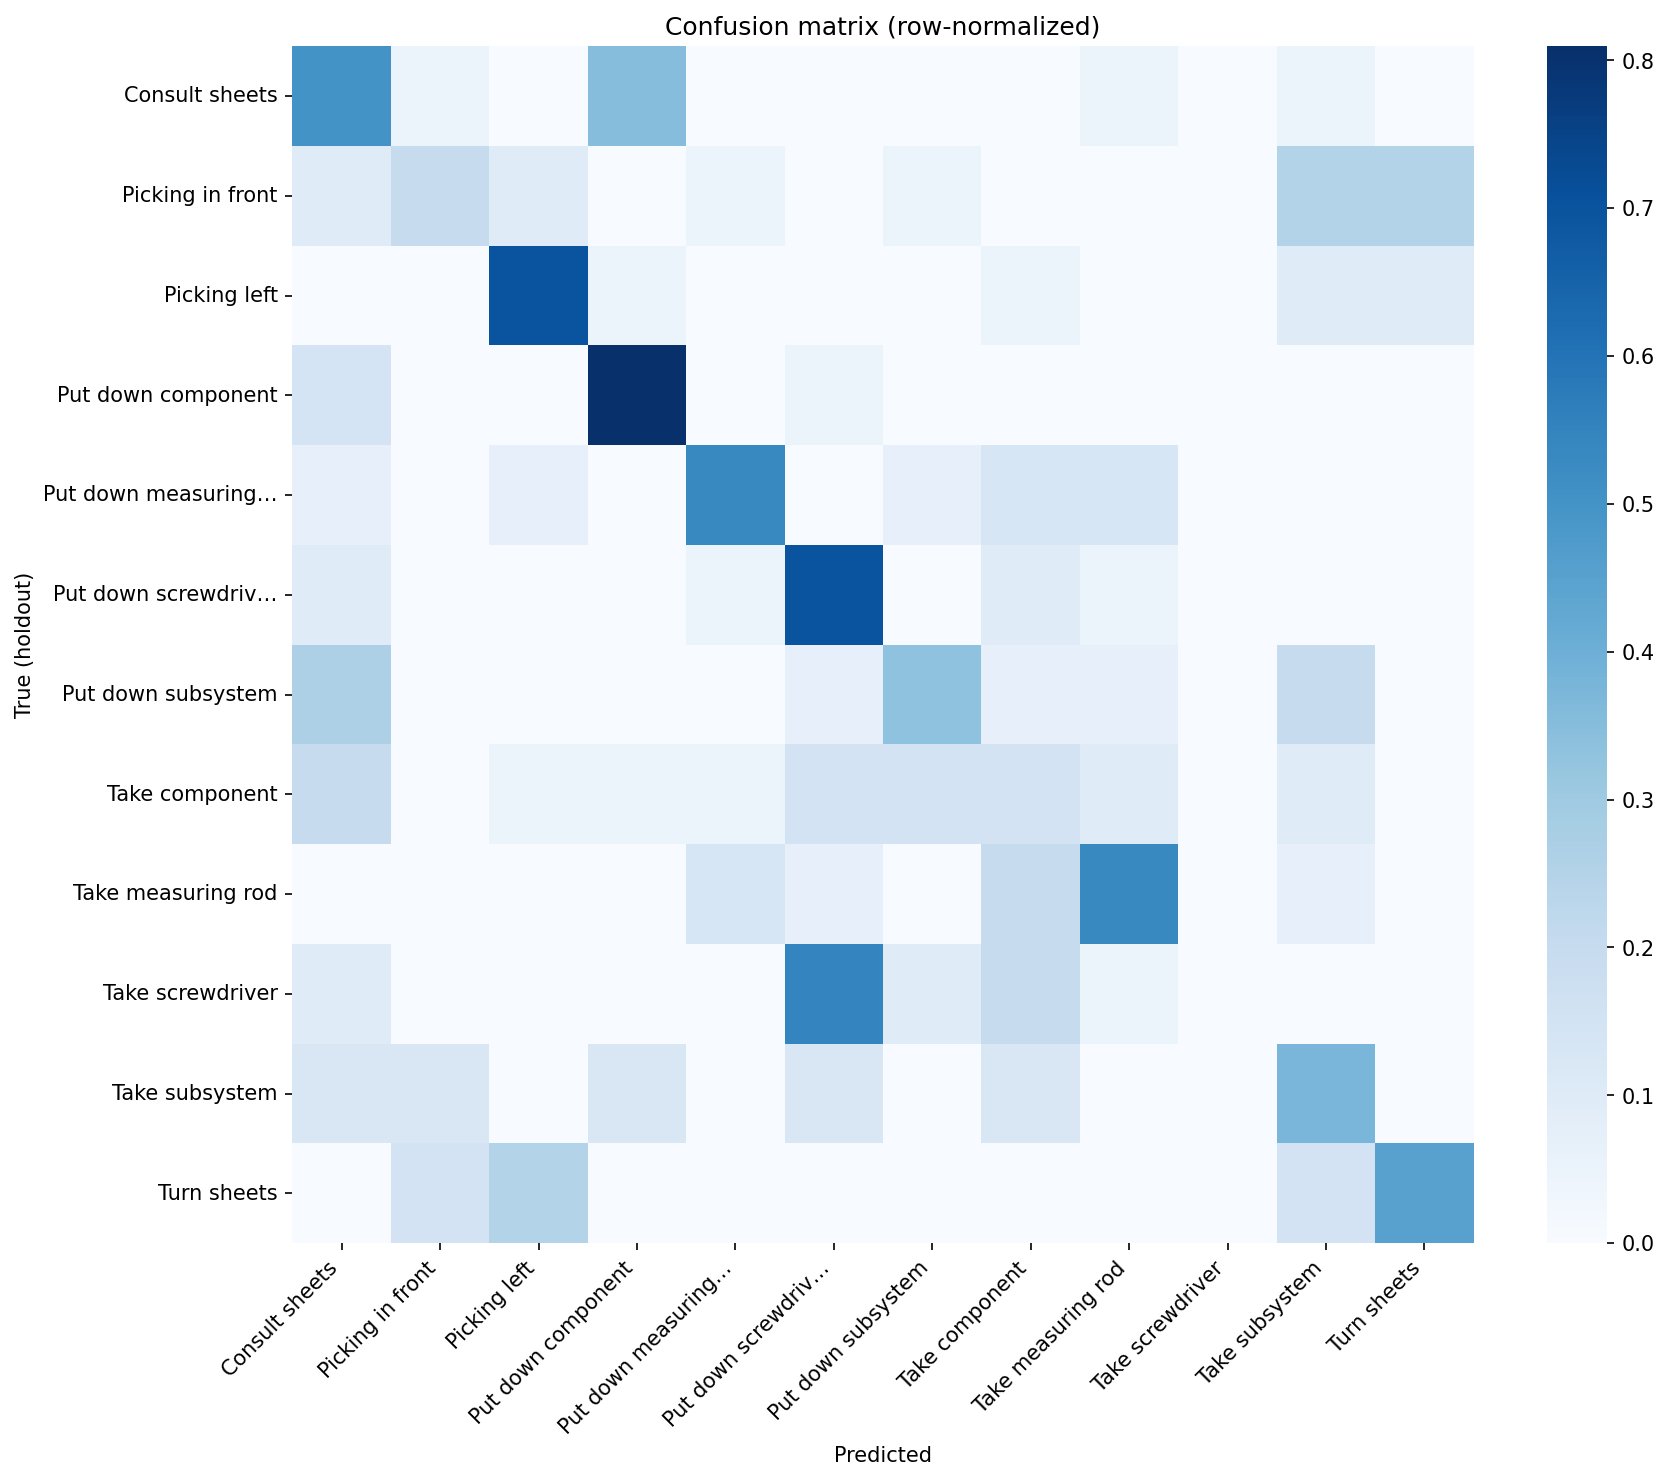

#### per_class_metrics

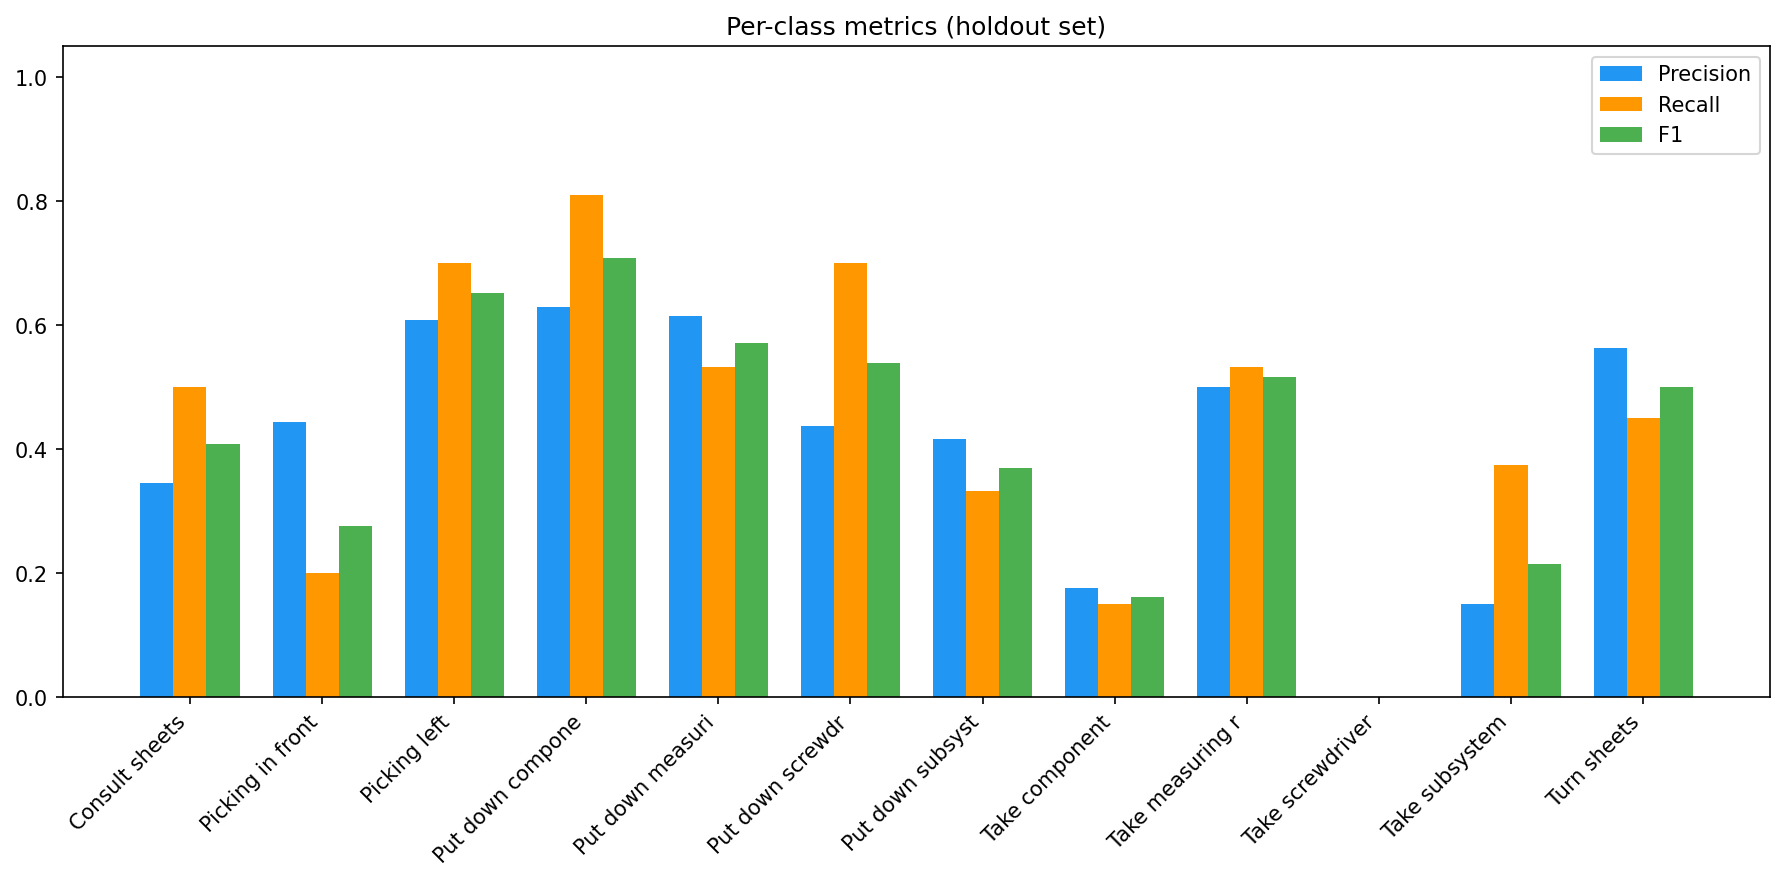

#### f1_heatmap

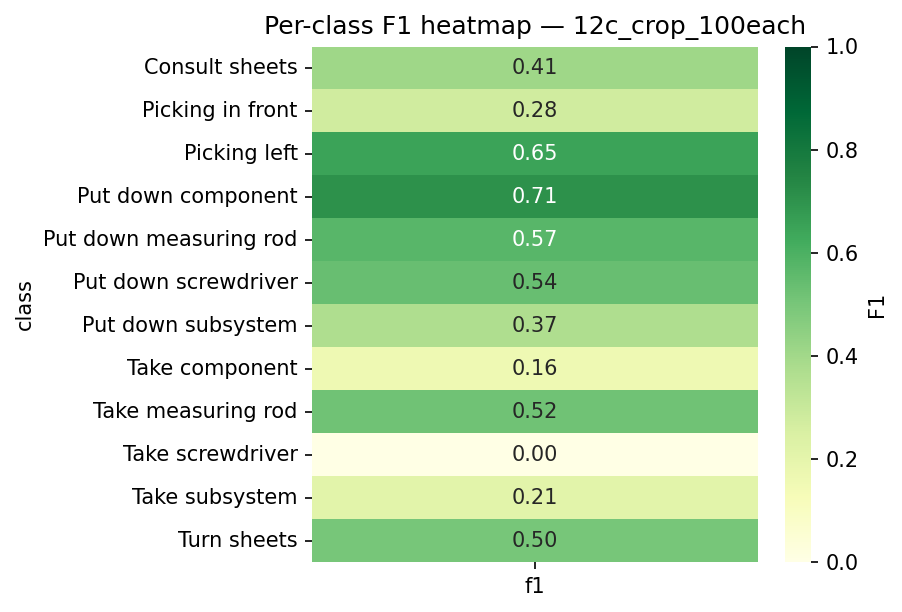

#### class_balance

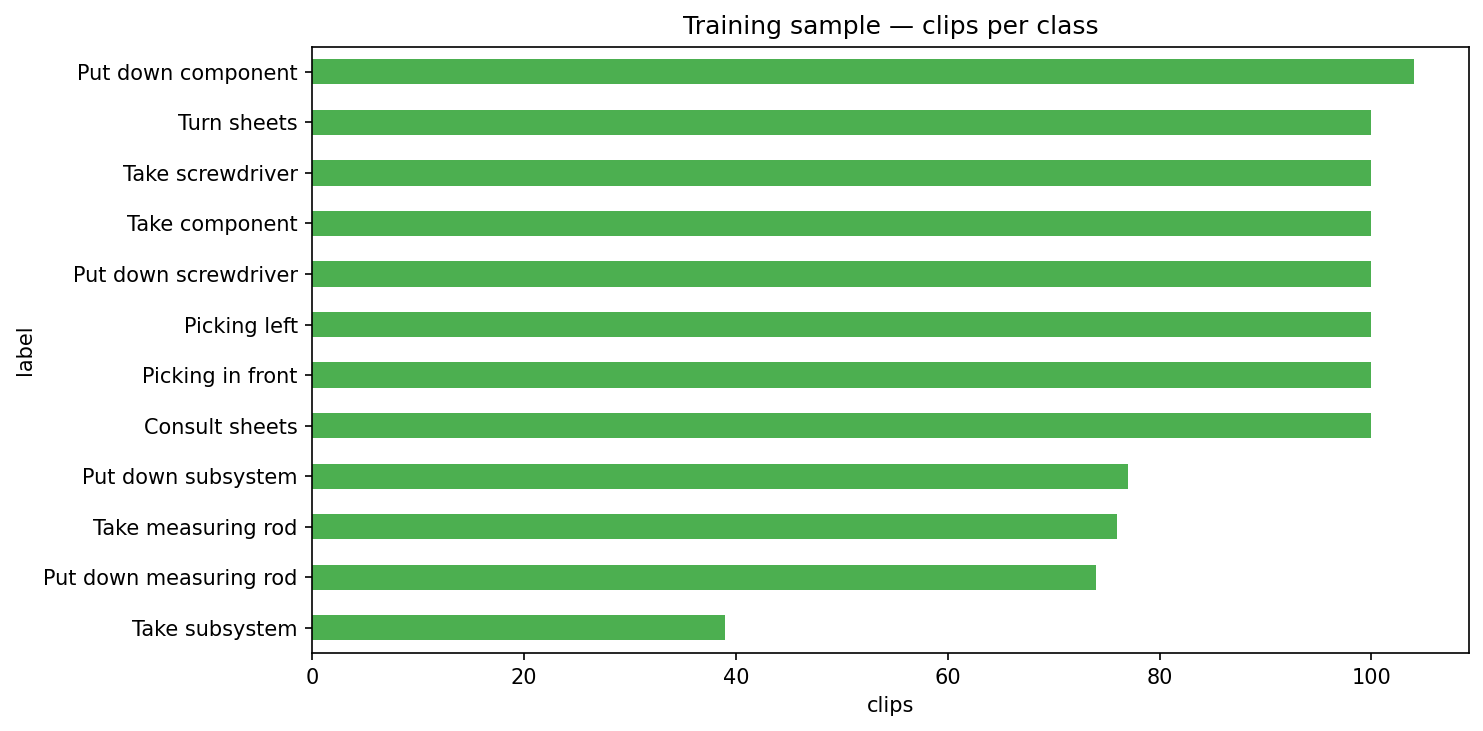

#### leaderboard

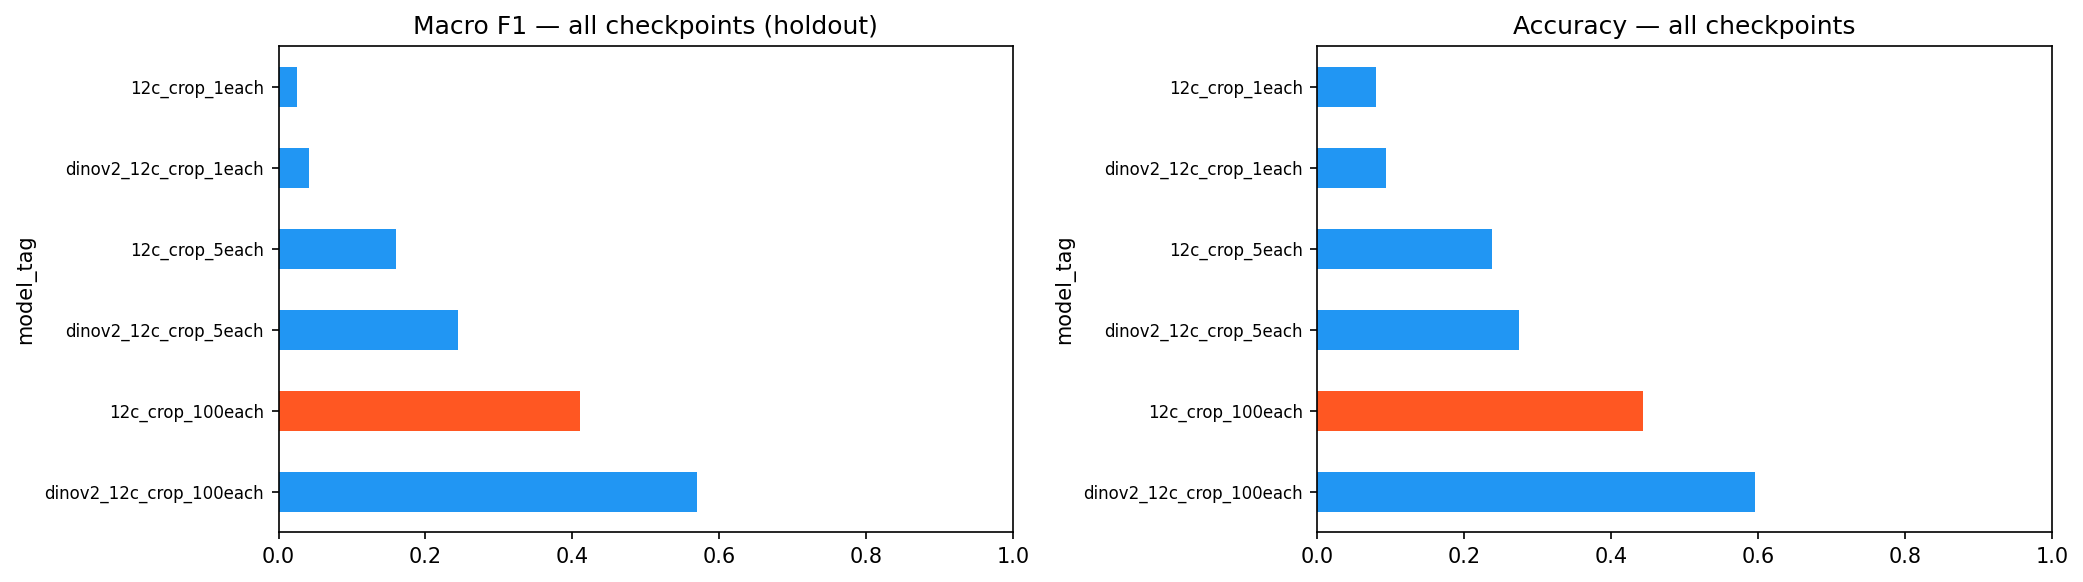

#### confidence_outliers

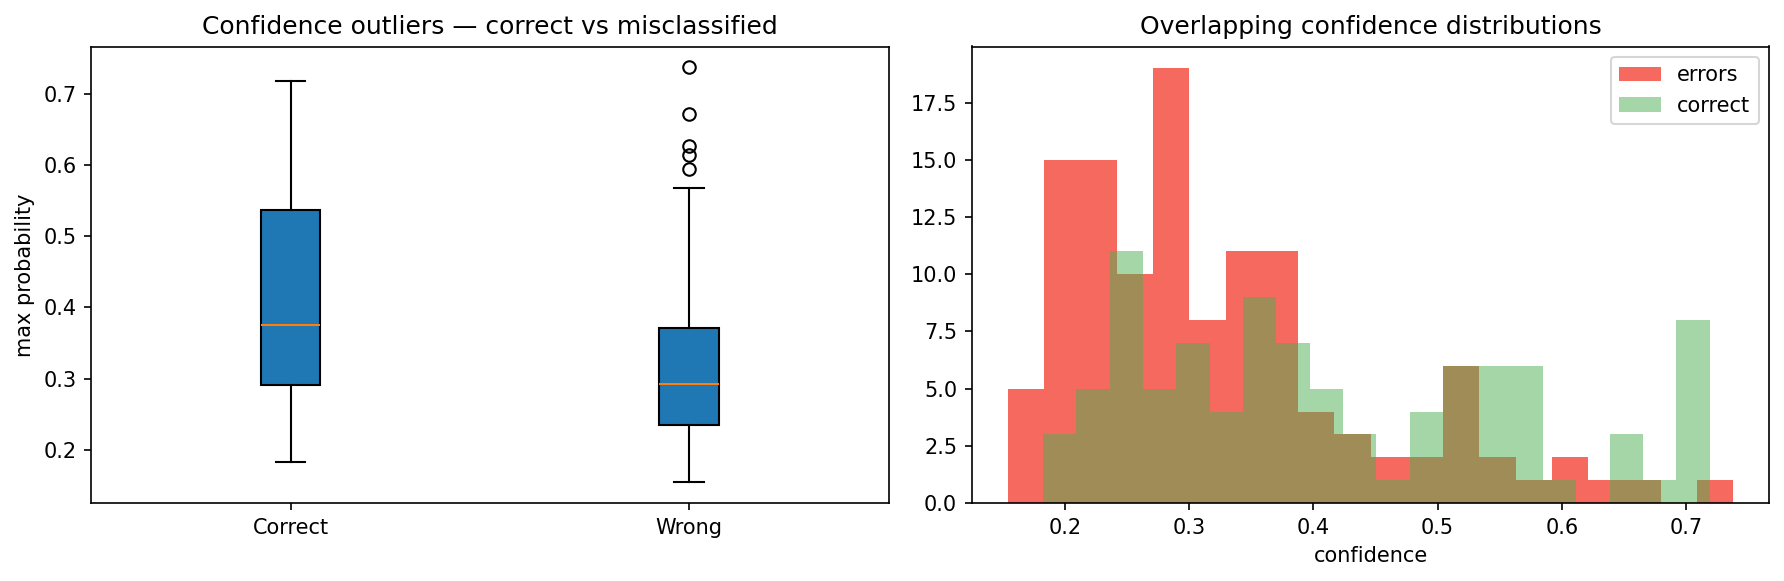

#### pca_clusters

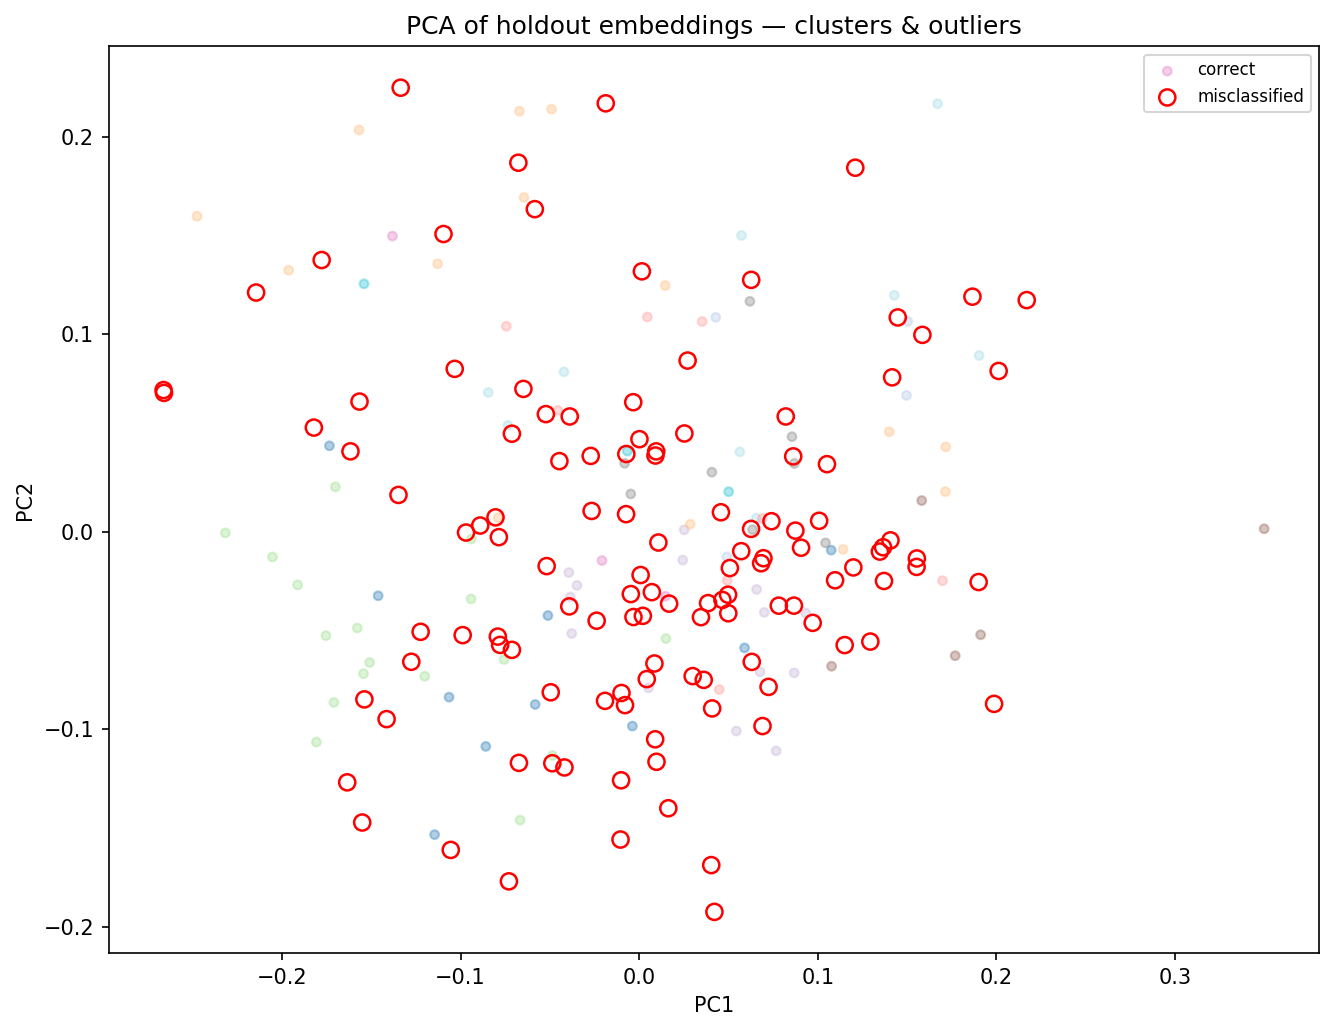

#### split_comparison

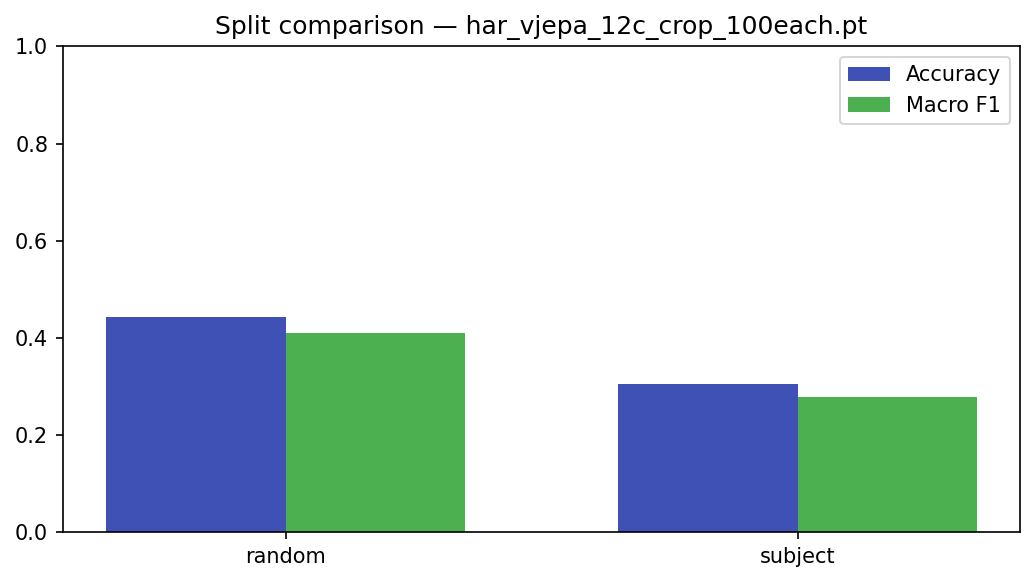

#### analysis_history

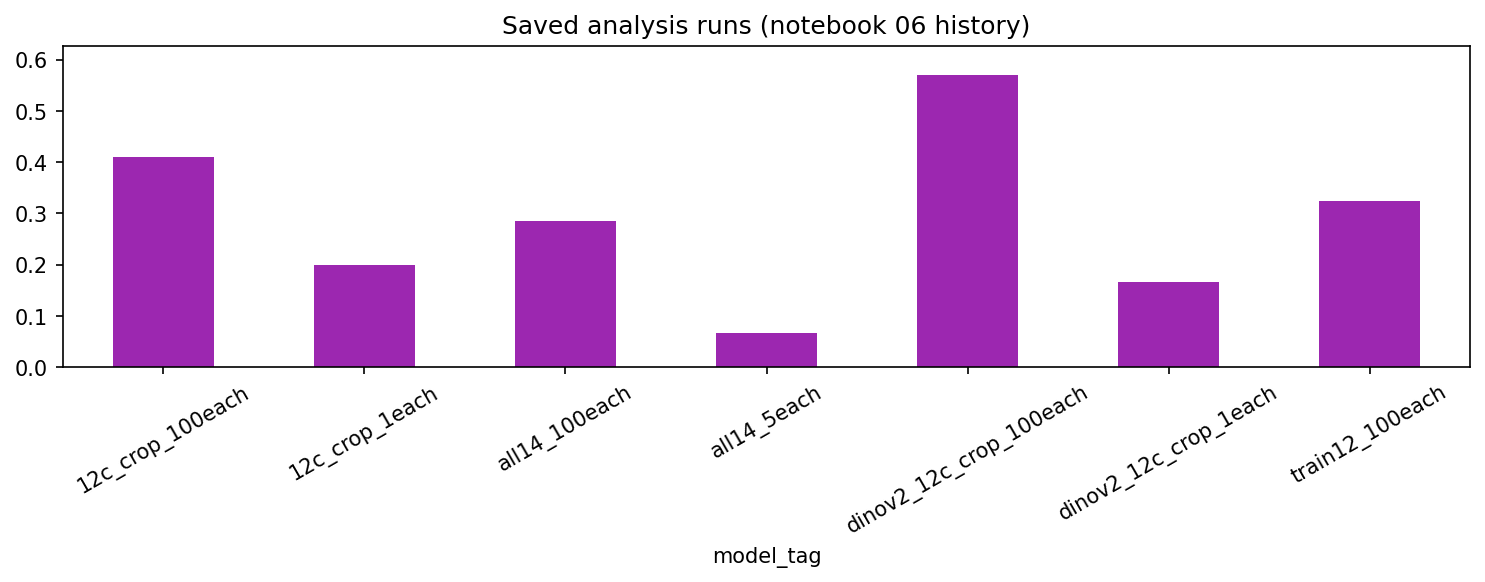

#### holdout_vs_live

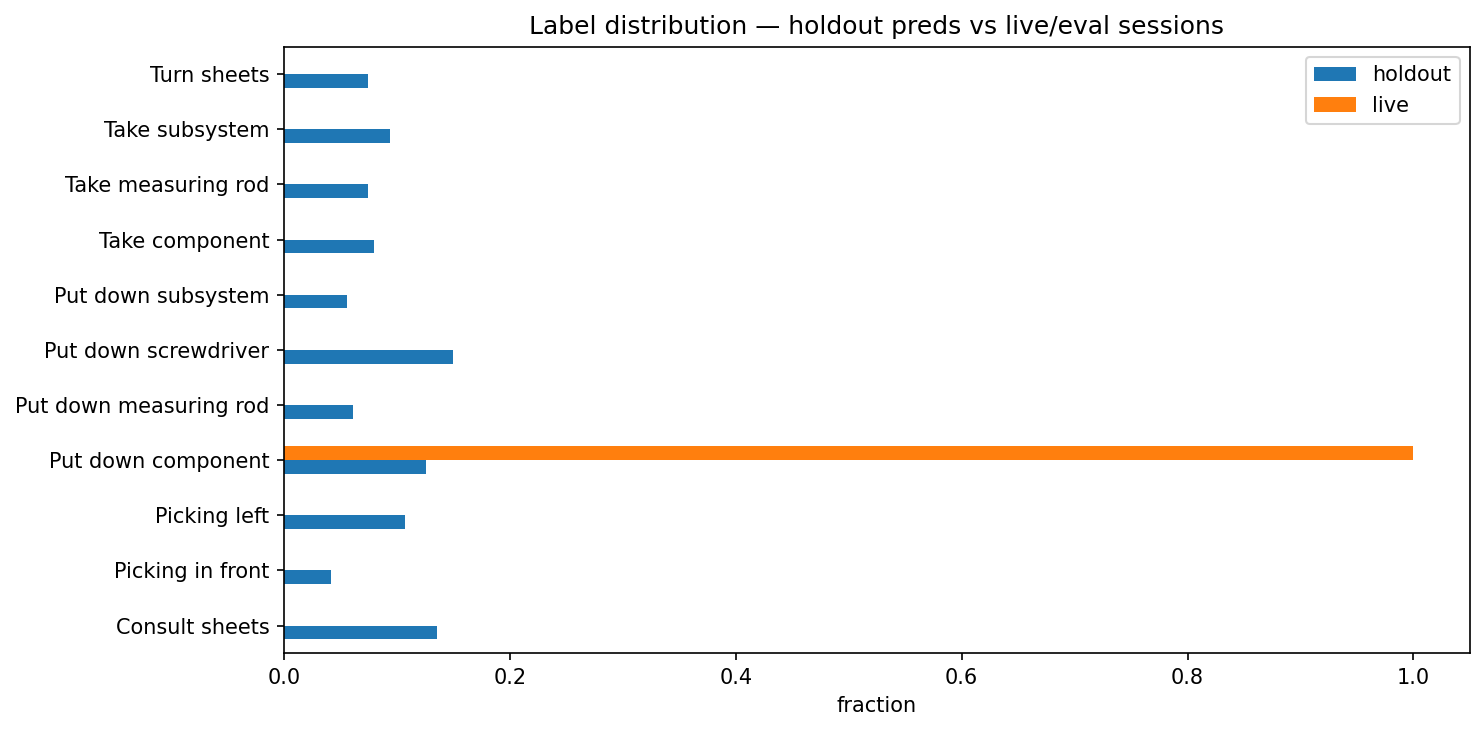

#### session_confidence

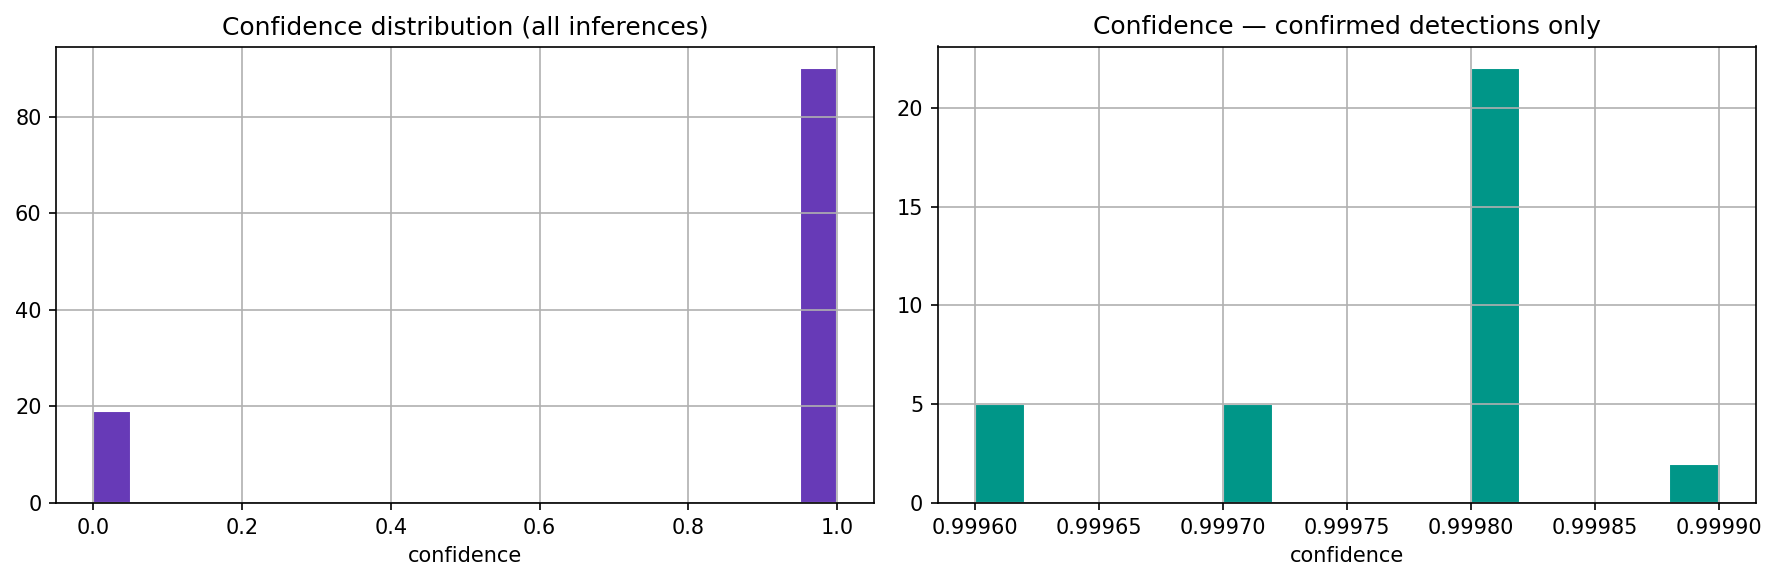

#### session_labels

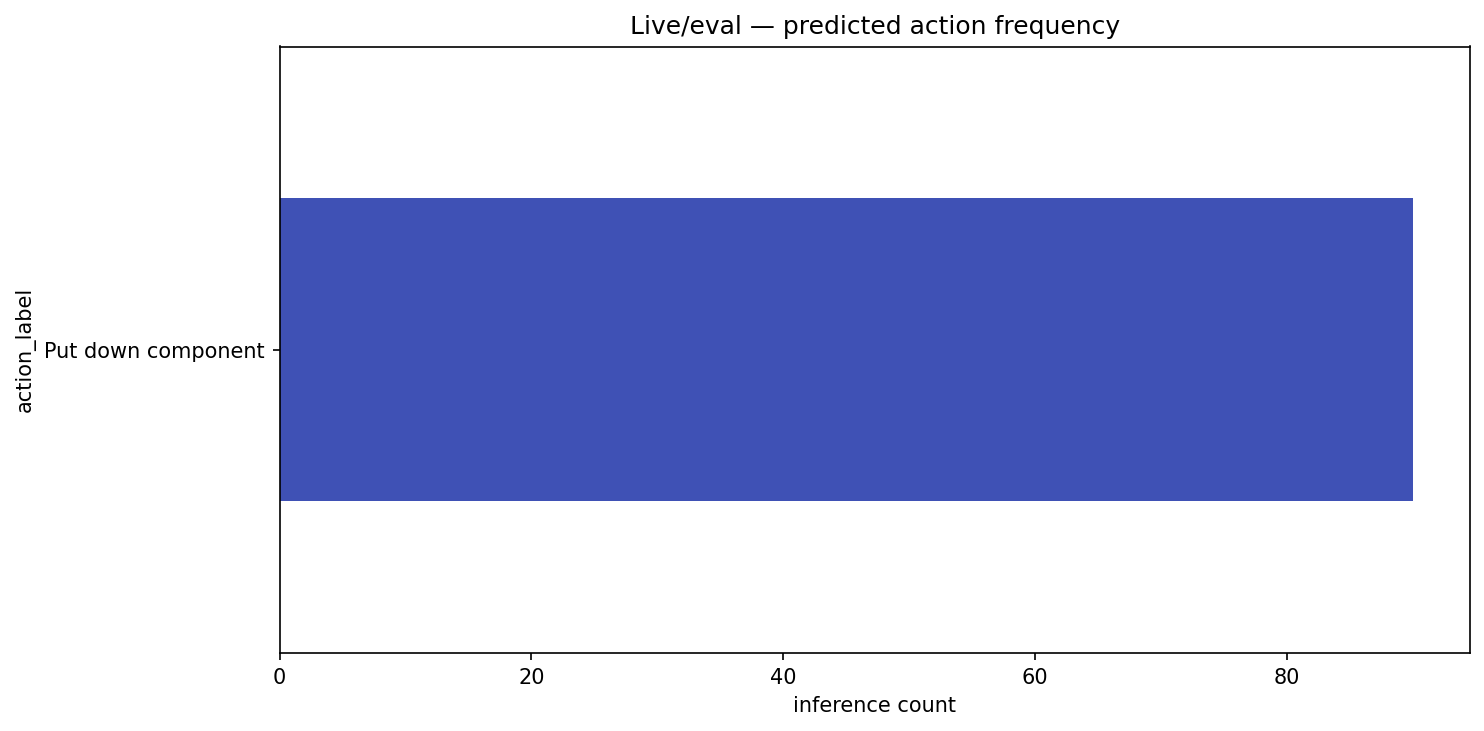

#### model_comparison

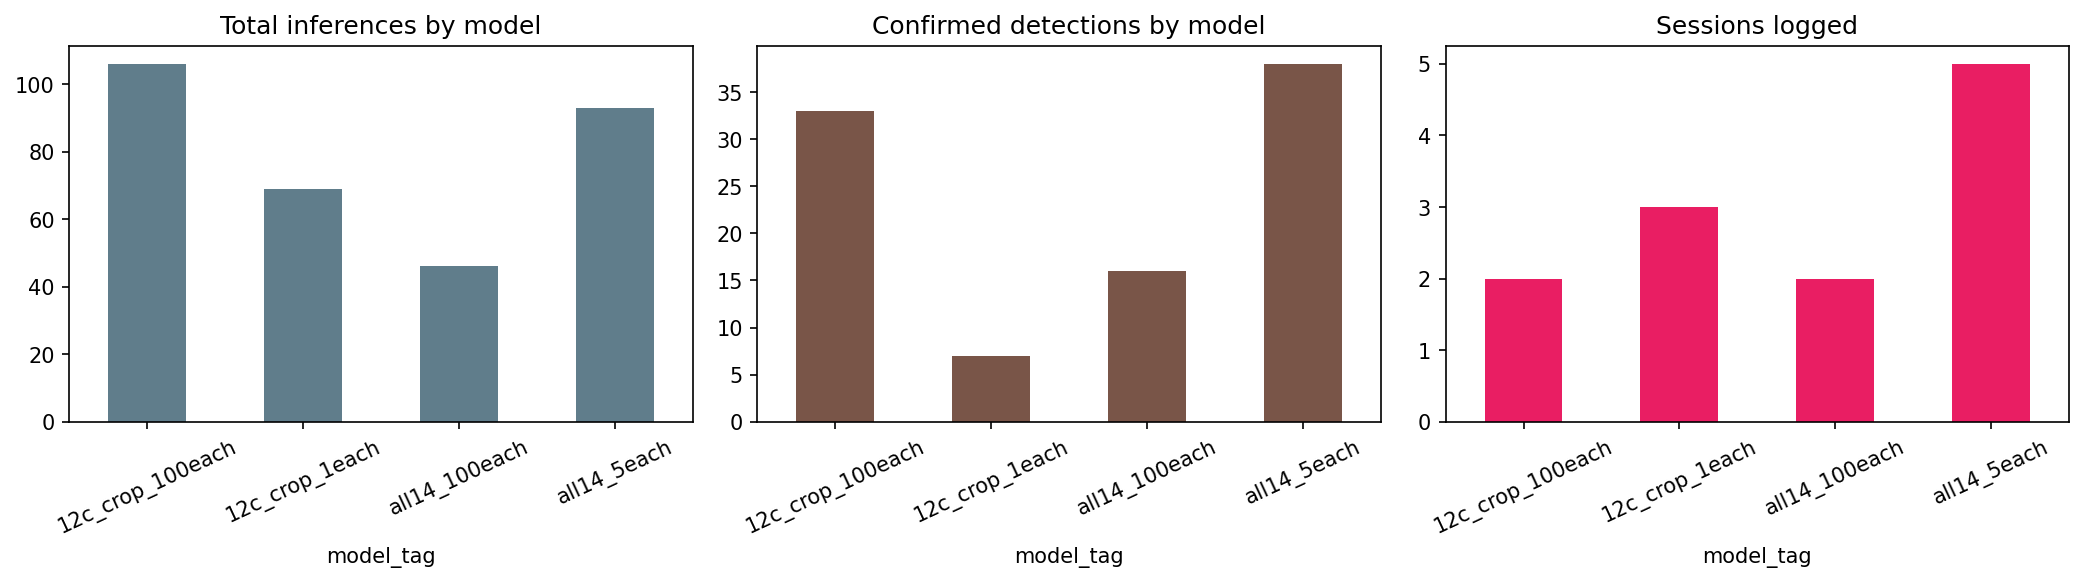

#### inference_latency

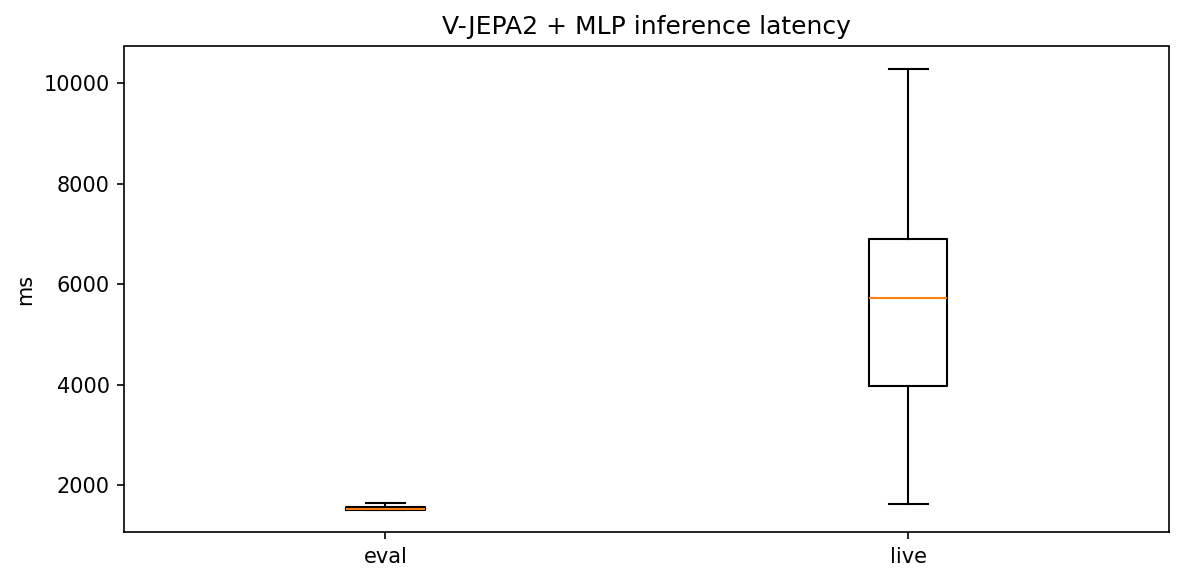

In [20]:
CHART_ORDER = [
    "confusion_matrix",
    "per_class_metrics",
    "f1_heatmap",
    "class_balance",
    "leaderboard",
    "confidence_outliers",
    "pca_clusters",
    "split_comparison",
    "analysis_history",
    "holdout_vs_live",
    "session_confidence",
    "session_labels",
    "model_comparison",
    "inference_latency",
    "training_loss",
]

charts = result["charts"]
for key in CHART_ORDER:
    path = charts.get(key)
    if not path:
        continue
    display(Markdown(f"#### {key}"))
    display(Image(filename=path, width=900))

# any extra charts not in CHART_ORDER
for key, path in sorted(charts.items()):
    if key in CHART_ORDER or not path:
        continue
    display(Markdown(f"#### {key}"))
    display(Image(filename=path, width=900))

## Checkpoint registry (`checkpoints/*.json`)

In [21]:
registry = load_checkpoint_registry()
display(registry)

display(Markdown("### Saved analysis runs (notebook 06 history)"))
history = load_analysis_history()
if history.empty:
    print("No prior runs in outputs/har_analysis/")
else:
    hist_cols = [c for c in ["analysis_run", "model_tag", "split", "n_test", "accuracy", "macro_f1", "n_live_events"] if c in history.columns]
    display(history[hist_cols].sort_values("macro_f1", ascending=False))

,checkpoint,model_tag,n_classes,n_samples,split_mode,embedding_mode,npz_path,epochs
0,har_vjepa_12c_crop_100each.pt,12c_crop_100each,12,1070,subject,yolo_crop,/Users/cpanoh/Documents/cpano-98-local/GitHub/...,25
1,har_vjepa_12c_crop_1each.pt,12c_crop_1each,12,17,subject,yolo_crop,/Users/cpanoh/Documents/cpano-98-local/GitHub/...,25
2,har_vjepa_12c_crop_5each.pt,12c_crop_5each,12,65,subject,yolo_crop,/Users/cpanoh/Documents/cpano-98-local/GitHub/...,25


### Saved analysis runs (notebook 06 history)

,analysis_run,model_tag,split,n_test,accuracy,macro_f1,n_live_events
4,2026-06-08_dinov2_12c_crop_100each,dinov2_12c_crop_100each,random,215,0.595349,0.569990,0
2,2026-06-08_12c_crop_100each,12c_crop_100each,random,214,0.443925,0.409697,109
6,2026-06-08_train12_100each,train12_100each,NaN,213,0.366197,0.324842,0
0,2026-06-07_all14_100each,all14_100each,NaN,253,0.320158,0.284592,46
3,2026-06-08_12c_crop_1each,12c_crop_1each,random,4,0.250000,0.200000,69
5,2026-06-08_dinov2_12c_crop_1each,dinov2_12c_crop_1each,random,4,0.250000,0.166667,0
1,2026-06-07_all14_5each,all14_5each,NaN,253,0.142292,0.067254,97


## Split comparison — subject vs random

Subject split can collapse to a tiny train set when `subjects` metadata is sparse (e.g. crop pipeline). Compare both splits on the **same** checkpoint.

In [22]:
npz = resolve_npz_for_checkpoint(CURRENT_CKPT)
rows = []
for split in ("random", "subject"):
    try:
        ev = eval_checkpoint_on_embeddings(CURRENT_CKPT, npz_path=npz, split=split)
        rows.append(
            {
                "split": split,
                "n_train": ev["n_train"],
                "n_test": ev["n_test"],
                "accuracy": ev["accuracy"],
                "macro_f1": ev["macro_f1"],
            }
        )
    except Exception as exc:
        rows.append({"split": split, "error": str(exc)})

split_df = pd.DataFrame(rows)
display(split_df)

if (split_df.get("n_train", pd.Series(dtype=float)) < 50).any():
    display(
        Markdown(
            "⚠️ **Low n_train on subject split** — metrics are not trustworthy. "
            "Prefer `HOLDOUT_SPLIT='random'` until subject metadata is fixed in embedding extraction."
        )
    )

,split,n_train,n_test,accuracy,macro_f1
0,random,856,214,0.443925,0.409697
1,subject,903,167,0.305389,0.279270


## Report

Open `REPORT.md` in the output folder for a text summary. Compare with `outputs/har_analysis/compare_14vs12_holdout.json` for the 14-class vs 12-class study.

In [23]:
report_path = result["report_path"]
if report_path.is_file():
    display(Markdown(report_path.read_text(encoding="utf-8")[:4000]))
else:
    print("No report yet")

# HAR Model Analysis — `12c_crop_100each`

Generated: 2026-06-08T14:02:17

## Model identity

| Field | Value |
|-------|-------|
| Checkpoint | `har_vjepa_12c_crop_100each.pt` |
| Embedding | `facebook/vjepa2-vitl-fpc64-256` |
| Classes | 12 |
| Train clips | 856 |
| Holdout clips | 214 |

## Holdout metrics (training set)

| Metric | Value |
|--------|-------|
| Accuracy | **44.4%** |
| Macro F1 | **0.410** |
| Weighted F1 | **0.417** |
| Macro precision | 0.407 |
| Macro recall | 0.440 |

## Live / eval sessions

- Sessions logged: **2**
- Total inferences: **106**
- Confirmed detections: **33**
- Mean confidence: **82.5%**
- Mean infer latency: **4755 ms**

## Charts

- `class_balance`: 01_train_class_balance.png
- `confusion_matrix`: 02_confusion_matrix.png
- `per_class_metrics`: 03_per_class_prf1.png
- `session_confidence`: 05_session_confidence.png
- `session_labels`: 06_session_label_distribution.png
- `model_comparison`: 07_model_comparison.png
- `inference_latency`: 08_inference_latency.png
